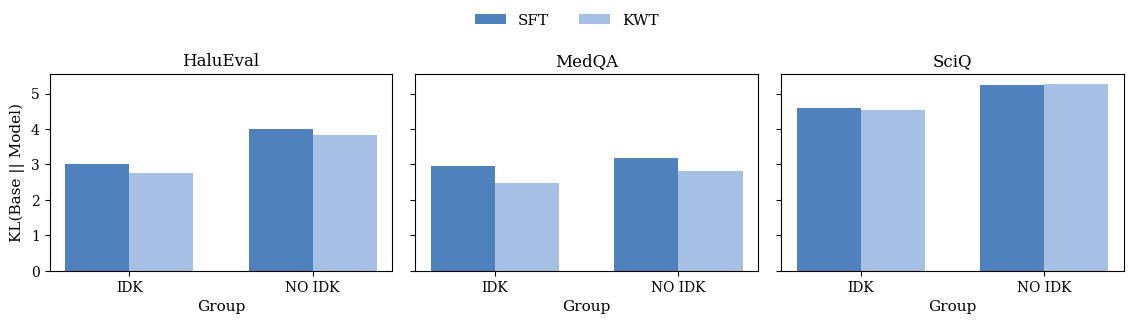

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl



# =========================
# ACL 스타일 폰트 설정
# =========================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times', 'Times New Roman', 'Nimbus Roman', 'DejaVu Serif']
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 11

# =========================
# 1. 데이터 입력 (IDK / NO-IDK만)
# =========================

datasets = ["HaluEval", "MedQA", "SciQ"]
groups = ["IDK", "NO IDK"]

means = {
    "HaluEval": {
        "SFT": [3.02, 4.00],
        "KWT": [2.77, 3.83],
    },
    "MedQA": {
        "SFT": [2.96, 3.18],
        "KWT": [2.48, 2.82],
    },
    "SciQ": {
        "SFT": [4.60, 5.23],
        "KWT": [4.53, 5.28],
    },
}

# =========================
# 2. 그래프 설정
# =========================

# 파란 계열 팔레트
color_sft = "#4F81BD"   # 진한 파랑
color_kwt = "#A6C0E4"   # 연한 파랑

num_groups = len(groups)
bar_width = 0.35
x = np.arange(num_groups)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.3), sharey=True)

for i, dataset in enumerate(datasets):
    ax = axes[i]

    sft_means = means[dataset]["SFT"]
    kwt_means = means[dataset]["KWT"]

    # bars
    ax.bar(
        x - bar_width/2, sft_means,
        width=bar_width, color=color_sft,
        label="SFT" if i == 0 else None
    )
    ax.bar(
        x + bar_width/2, kwt_means,
        width=bar_width, color=color_kwt,
        label="KWT" if i == 0 else None
    )

    ax.set_title(dataset)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)

    if i == 0:
        ax.set_ylabel("KL(Base || Model)")
    # ax.set_xlabel("Group")

# 공통 legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("./figure/kl_idk_nonidk_acl_blue.pdf", dpi=300, bbox_inches="tight")
plt.show()
